<a href="https://colab.research.google.com/github/Napassornmp/Project_Bank-Analysis/blob/main/Seed_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Present
The Dataset present about the difference of weat seed characteristics. There are 7 features including  
1.area A

2.perimeter P

3.compactness C = 4piA/P^2

4.length of kerne

5.width of kernel

6.asymmetry coefficient

7.length of kernel groove


1. area A :พื้นที่ของเมล็ดในภาพ 2D
2. perimeter P :ความยาวรอบขอบเขตของเมล็ด
3. compactness C = 4*pi*A/P^2 :รูปร่างใกล้วงกลมแค่ไหน
4. length of kerne :ความยาวเมล็ด
5. width of kernel:ความกว้างเมล็ด
6. asymmetry coefficient : วัดว่าเมล็ดเอียงหรือเบี้ยวจากแกนกลางแค่ไหน
7. length of kernel groove :ความยาวร่องกลางเมล็ด (crease/groove)

# Analysis & Modeling
We will develope an appropriated classification model to identify and predict the varities of weat seeds and analyze feature which high influence. The model is considered to be SVM/ Logistic Regression.Due to the dataset are small size(n=210) with low-dimensional features (7 features) and Balanced data.

# Technique
1.Feature Extraction using Linear Discriminant Analysis (LDA) because
LDA is supervised learning dimensionality reduction technique and Machine Learning classifier. Furthermore, it Works well on small datasets. These LDA character are appropriate for the goal, Classify the varieties of weat seeds and help us retrive Feature Influence Insight.

In [29]:
import pandas as pd

# ชื่อคอลัมน์
columns = [
    "AreA",
    "P",
    "Compactness",
    "Kernel_Length",
    "Kernel_Width",
    "Asymmetry_Coeff",
    "GrooveLength",
    "lass"
]

# อ่านไฟล์ txt (คั่นด้วย space)
df = pd.read_csv("/content/drive/MyDrive/TOOL4STAT/seeds_dataset.txt", sep="\s+", header=None)

# ใส่หัวตาราง
df.columns = columns

# บันทึกไฟล์ใหม่
#df.to_csv("wheat_with_header.txt", sep="\t", index=False)


<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3300534783.py:16: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("/content/drive/MyDrive/TOOL4STAT/seeds_dataset.txt", sep="\s+", header=None)


In [30]:
df.head()

,AreA,P,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coeff,GrooveLength,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [31]:
#unique values for each column
df.nunique()


,0
AreA,193
P,170
Compactness,186
Kernel_Length,188
Kernel_Width,184
Asymmetry_Coeff,207
GrooveLength,148
Class,3


In [38]:
df["Weat_Variety"] = df["Class"].map({
    1: "Kama",
    2: "Rosa",
    3: "Canadian"
})


In [39]:
df.head()

,AreA,P,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coeff,GrooveLength,Class,Weat_Variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama


In [40]:
import matplotlib.pyplot as plt

Weat_Variety
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64


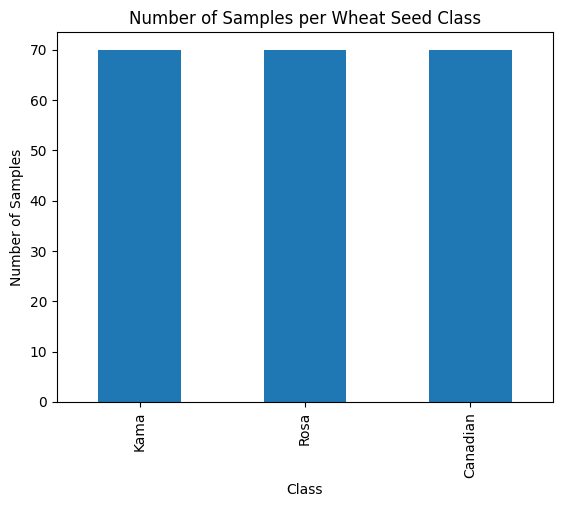

In [41]:
class_counts = df["Weat_Variety"].value_counts()
print(class_counts)

class_counts.plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Number of Samples per Wheat Seed Class")
plt.show()


In [45]:
df.isnull().sum()


,0
AreA,0
P,0
Compactness,0
Kernel_Length,0
Kernel_Width,0
Asymmetry_Coeff,0
GrooveLength,0
Class,0
Weat_Variety,0


In [46]:
import numpy as np
import numba
import pandas as pd
import scipy.special
import scipy.stats as st
import sklearn


In [48]:
import mpl_toolkits.mplot3d
import seaborn as sns

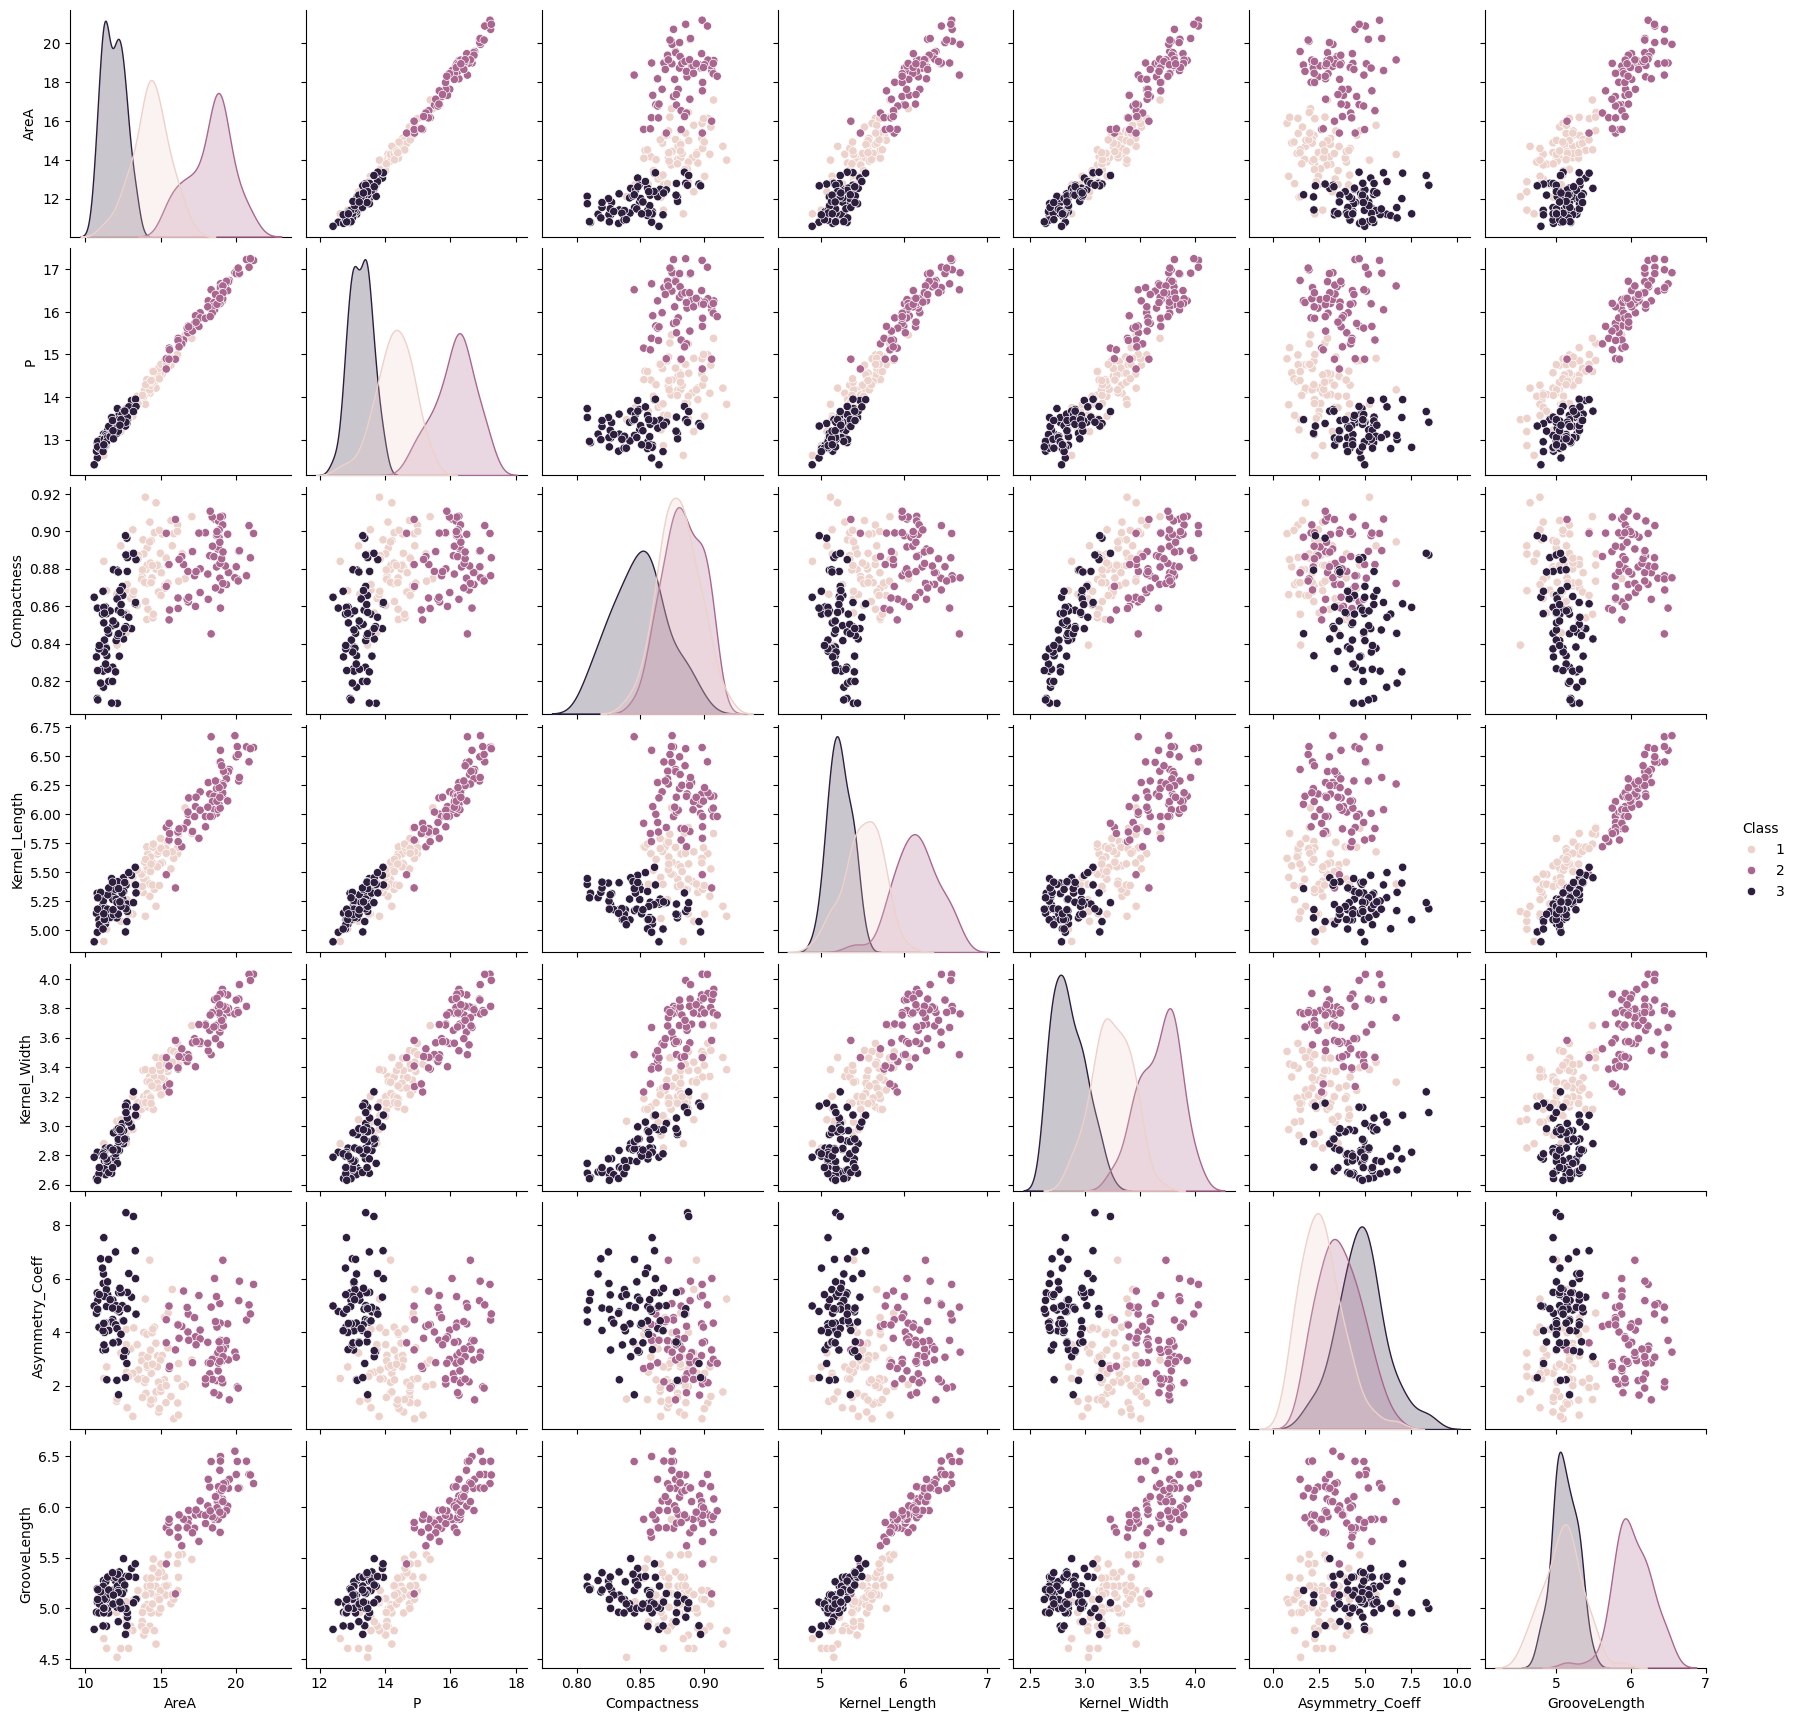

In [49]:

# Plot pairwise comparison to explore the data
_ = sns.pairplot(df, hue='Class')